## Notebook 05: **Multi-Window Semantic Analysis**

## Purpose of This Notebook

This notebook evaluates whether the selected proxy signals provide **consistent semantic advantages across multiple windows**.

Previous notebooks established:

- Notebook 01: a validated baseline and preliminary evidence.
- Notebook 02: a structured multi-window temporal framework.
- Notebook 03: a set of stable and interpretable proxy variants.
- Notebook 04: confirmation that these proxies behave consistently across windows.

This notebook now addresses the central question:

> Do these proxy signals improve semantic structure across multiple windows, not just a single frame or short segment?

---

## Why This Notebook Exists

The preliminary stage demonstrated that the proxy:

$$
\hat{\rho} = I \cdot R
$$

can improve semantic separability on a single frame and maintain structure over short windows.

However, those findings were:

- localized,
- limited in temporal scope,
- and not sufficient for sequence-level conclusions.

To move toward a final-stage contribution, we must evaluate:

- multiple windows,
- different parts of the sequence,
- and variation across scene conditions.

This notebook converts:

> “proxy works in one example”

into:

> “proxy behavior across many temporal segments”

## Core Idea

We now operate over a set of windows:

$$
\mathcal{W} = \{W_1, W_2, \dots, W_K\}
$$

Each window contains frames with semantic labels.

For each window $W_k$, and each proxy $\phi_j$, we compute **class-wise signal structure**.

This produces:

$$
S_{k,j} = \text{semantic structure of proxy } \phi_j \text{ in window } W_k
$$

The goal is to analyze:

$$
\{S_{k,j}\}_{k=1}^K
$$

instead of relying on a single window.

## Mathematical Framework

### 1. Signals

For each point $i$:

$$
I_i, \quad R_i = \sqrt{x_i^2 + y_i^2 + z_i^2}
$$

Proxy variants:

$$
\phi_0 = I
$$

$$
\phi_1 = I \cdot R
$$

$$
\phi_2 = \log(1 + I \cdot R)
$$

### 2. Semantic Labels

Each point has a semantic label:

$$
y_i \in \mathcal{C}
$$

where $\mathcal{C}$ is the set of semantic classes.

We define:

$$
\mathcal{C}_k = \text{valid classes in window } W_k
$$

after filtering:

- ignore labels (e.g., 0, 255).
- minimum support threshold.

### 3. Class-wise Statistics

For each class \( c \in \mathcal{C}_k \):

$$
\mu_{c,k,j} = \text{mean of } \phi_j \text{ for class } c \text{ in window } W_k
$$

$$
\sigma_{c,k,j} = \text{std of } \phi_j \text{ for class } c
$$

These define the class-level signal structure.

### 4. Multiclass Separability

We compute a Fisher-style separability score:

$$
S_{k,j} = \frac{\text{between-class variance}}{\text{within-class variance}}
$$

Formally:

$$
S = \frac{\sum_c n_c (\mu_c - \mu)^2}{\sum_c n_c \sigma_c^2}
$$

where:

- $n_c$: number of points in class $c$.
- $\mu_c$: class mean.
- $\mu$: global mean.

### 5. Per-Window Gain

We define:

$$
\Delta S_k = S_{k,\text{proxy}} - S_{k,\text{raw}}
$$

This measures whether the proxy improves semantic separability in each window.

### 6. Rank Consistency

We evaluate whether class ordering is preserved across time.

For each window:

- compute class mean vector.
- compare with reference ordering using Spearman correlation:

$$
\rho_k = \text{Spearman}(\text{class ordering})
$$

## Core Questions This Notebook Answers

#### 1. Does the proxy improve separability across windows?

- consistent gain vs occasional gain

#### 2. Is the improvement stable?

- or does it vary significantly across windows?

#### 3. Which classes benefit?

- consistent vs weak vs negative impact

#### 4. Does class ordering remain stable across motion?

- does temporal structure survive?

## What This Notebook Will Do

Step-by-step:

1. Load window metadata and iterate over windows.
2. Load LiDAR frames and semantic labels.
3. Filter valid classes.
4. Compute class-wise statistics for each proxy.
5. Compute separability scores per window.
6. Compute gain relative to raw intensity.
7. Evaluate rank consistency across windows.
8. Aggregate results across all windows.
9. Identify patterns of improvement and failure.

## What This Notebook Is Not Allowed to Do

This notebook must remain disciplined.

It must not:

- claim segmentation performance improvement
- claim material identification
- assume universal proxy superiority
- generate videos or GIFs
- overgeneralize from local results

All conclusions must remain:

- empirical,
- window-based,
- and explicitly qualified.

## Expected Outputs

By the end of this notebook, we should have:

- per-window separability scores.
- gain distributions across windows.
- class-wise statistics across windows.
- rank consistency plots.
- aggregated semantic summary tables.

## Expected Outcomes

If the proxy is meaningful, we expect:

- positive separability gain in many windows.
- variability across windows (not uniform).
- certain classes consistently benefiting.
- some classes showing weak or negative effects.
- log-scaled proxy to show more stable behavior.

## Core Honesty Statement

This notebook evaluates semantic structure using heuristic signals.

The proxy:

$$
\hat{\rho} = I \cdot R
$$

and its variants:

- are not calibrated reflectivity,
- remain range-dependent,
- and are not guaranteed to improve all classes or all scenes.

Observed gains must be interpreted as:

> signal-level improvements in semantic structure, not definitive performance claims.

## Expected Final Takeaway of This Notebook

If this notebook succeeds, we will have:

> a multi-window, class-aware evaluation of proxy usefulness, showing where the proxy helps, where it does not, and how consistently those effects occur across the sequence.

This forms the strongest evidence in the project before:

- failure-case analysis,
- and downstream task evaluation.

---

## Load Window Metadata and Initialize Semantic Analysis

We begin by loading the validated multi-window structure and preparing the semantic analysis pipeline.

Unlike previous notebooks, this stage introduces:

- semantic labels,
- class-wise computations,
- and per-window semantic evaluation.

For each window, we will:

- reconstruct frame indices,
- load LiDAR scans and corresponding semantic labels,
- ensure point-label alignment,
- and prepare data for class-wise analysis.

At this stage, we do not yet compute semantic metrics.

We only:

- load data,
- verify integrity,
- and establish a consistent pipeline for semantic evaluation.

This step ensures that all subsequent computations operate on:

- correctly aligned point-label data,
- valid semantic classes,
- and reproducible window definitions.

In [8]:
import numpy as np
import pandas as pd
from pathlib import Path

# Step 0: Resolve dataset root
candidate_roots = [
    Path("../data/semantickitti_subset/dataset/sequences/00"),
    Path("../data/semantickitti/dataset/sequences/00"),
]

DATASET_ROOT = next((p for p in candidate_roots if p.exists()), candidate_roots[0])

print("Dataset Root:", DATASET_ROOT.resolve())
print("Exists:", DATASET_ROOT.exists())

# Step 1: Load window metadata
metadata_path = Path("../results/window_metadata/sequence00_windows.csv")
window_df = pd.read_csv(metadata_path)

print("\nLoaded Window Metadata")
print()
print("Shape:", window_df.shape)

# Step 2: Prepare directories
velodyne_dir = DATASET_ROOT / "velodyne"
labels_dir = DATASET_ROOT / "labels"

# Step 3: Reconstruct global frame list
FRAME_IDS = sorted([f.stem for f in velodyne_dir.glob("*.bin")])

print("\nGlobal Frame Info")
print()
print("Total frames:", len(FRAME_IDS))
print("First frame :", FRAME_IDS[0])
print("Last frame  :", FRAME_IDS[-1])

# Step 4: Initialize container
semantic_window_data = []

print("\nInitialized semantic analysis pipeline.")

Dataset Root: /home/twilightpriest/GitHub/reflect-aug-seg/data/semantickitti/dataset/sequences/00
Exists: True

Loaded Window Metadata

Shape: (15, 7)

Global Frame Info

Total frames: 4541
First frame : 000000
Last frame  : 004540

Initialized semantic analysis pipeline.


## Load a Single Window with Semantic Labels

Before processing all windows, we validate the semantic pipeline on a single window.

For a selected window, we:

- reconstruct frame IDs,
- load LiDAR scans,
- load corresponding semantic labels,
- verify point-label alignment,
- extract semantic class IDs.

Each label is stored as a 32-bit integer:

$$
\text{label} = \text{semantic\_id} + (\text{instance\_id} << 16)
$$

We extract:

$$
\text{semantic\_id} = \text{label} \,\&\, 0xFFFF
$$

This step ensures:

- correct label loading,
- correct alignment with point cloud,
- valid semantic data for downstream analysis.

We do not compute any metrics yet.

This is purely a **sanity check for semantic data integrity**.

In [9]:
# Select one window (same as before: medium_0)
selected_row = window_df[
    (window_df["scale"] == "medium")
].iloc[0]

start_idx = int(selected_row["start_idx"])
end_idx = int(selected_row["end_idx"])
length = int(selected_row["length"])

print("Selected Window")
print()
print("Window ID   :", selected_row["window_id"])
print("Start idx   :", start_idx)
print("End idx     :", end_idx)
print("Length      :", length)

# Reconstruct frame IDs
frame_ids = FRAME_IDS[start_idx:end_idx + 1]

assert len(frame_ids) == length

# Load data
all_xyz = []
all_intensity = []
all_labels = []

for fid in frame_ids:
    bin_path = velodyne_dir / f"{fid}.bin"
    label_path = labels_dir / f"{fid}.label"
    
    scan = np.fromfile(bin_path, dtype=np.float32).reshape(-1, 4)
    labels = np.fromfile(label_path, dtype=np.uint32)
    
    xyz = scan[:, :3]
    intensity = scan[:, 3]
    
    # Alignment check
    assert len(xyz) == len(labels), f"Mismatch in frame {fid}"
    
    all_xyz.append(xyz)
    all_intensity.append(intensity)
    all_labels.append(labels)

# Concatenate
xyz = np.concatenate(all_xyz, axis=0)
intensity = np.concatenate(all_intensity, axis=0)
labels = np.concatenate(all_labels, axis=0)

# Extract semantic labels
semantic_labels = labels & 0xFFFF

print("\nLoaded Semantic Window")
print()
print("Total points :", xyz.shape[0])
print("Intensity    :", intensity.shape)
print("Labels       :", labels.shape)
print("Semantic     :", semantic_labels.shape)

# Inspect classes
unique_classes, counts = np.unique(semantic_labels, return_counts=True)

print("\nNumber of classes in window:", len(unique_classes))
print("First 10 classes:")
for cls, cnt in zip(unique_classes[:10], counts[:10]):
    print(f"Class {cls:>3}: {cnt}")

Selected Window

Window ID   : medium_0
Start idx   : 0
End idx     : 29
Length      : 30

Loaded Semantic Window

Total points : 3697281
Intensity    : (3697281,)
Labels       : (3697281,)
Semantic     : (3697281,)

Number of classes in window: 22
First 10 classes:
Class   0: 73946
Class   1: 1428
Class  10: 207772
Class  20: 217
Class  32: 2
Class  40: 823757
Class  44: 284408
Class  48: 512183
Class  50: 846403
Class  51: 27481


## Filter Valid Semantic Classes

Before computing semantic metrics, we filter the set of classes used in analysis.

Raw semantic labels include:

- ignored classes (e.g., 0, 255),
- very small classes with insufficient support.

These can introduce:

- unstable statistics,
- noisy separability estimates,
- misleading results.

We define a set of valid classes:

$$
\mathcal{C}_{valid} = \{c \mid n_c \geq \text{min\_points},\; c \notin \{0, 255\}\}
$$

where $n_c$ is the number of points in class $c$.

This ensures:

- robust class-wise statistics,
- meaningful separability computation,
- consistent evaluation across windows.

This step is essential for stable semantic analysis.

In [10]:
from collections import Counter

# Count class occurrences
class_counts = Counter(semantic_labels.tolist())

# Define filtering rules
ignore_labels = {0, 255}
min_points = 500

# Select valid classes
valid_classes = sorted([
    cls for cls, cnt in class_counts.items()
    if cls not in ignore_labels and cnt >= min_points
])

print("Valid Classes for Analysis")
print()

for cls in valid_classes:
    print(f"Class {cls:>3}: {class_counts[cls]} points")

print("\nTotal valid classes:", len(valid_classes))

Valid Classes for Analysis

Class   1: 1428 points
Class  10: 207772 points
Class  40: 823757 points
Class  44: 284408 points
Class  48: 512183 points
Class  50: 846403 points
Class  51: 27481 points
Class  52: 19624 points
Class  60: 8640 points
Class  70: 732008 points
Class  71: 86963 points
Class  72: 34835 points
Class  80: 15800 points
Class  81: 4050 points
Class  99: 16050 points

Total valid classes: 15


## Compute Semantic Separability

We now evaluate how well each signal separates semantic classes.

For each proxy $\phi$, we compute a Fisher-style separability score:

$$
S = \frac{\sum_c n_c (\mu_c - \mu)^2}{\sum_c n_c \sigma_c^2}
$$

where:

- $n_c$: number of points in class $c$.
- $\mu_c$: mean signal value for class $c$.
- $\sigma_c^2$: variance within class $c$.
- $\mu$: global mean across all classes.

Interpretation:

- high $S$ → better class separation.
- low $S$ → overlapping class distributions.

We compute this for:

- raw intensity $I$.
- proxy $I \cdot R$.
- log-scaled proxy $\log(1 + I \cdot R)$.

This provides a direct measure of semantic usefulness for each signal.

In [11]:
def fisher_separability(signal, labels, classes):
    class_means = []
    class_vars = []
    class_ns = []

    for cls in classes:
        vals = signal[labels == cls]
        class_means.append(vals.mean())
        class_vars.append(vals.var())
        class_ns.append(len(vals))

    class_means = np.array(class_means)
    class_vars = np.array(class_vars)
    class_ns = np.array(class_ns)

    global_mean = np.average(class_means, weights=class_ns)

    between = np.sum(class_ns * (class_means - global_mean) ** 2)
    within = np.sum(class_ns * class_vars)

    score = between / (within + 1e-12)

    return score, class_means, class_vars, class_ns


# Signals
I = intensity
R = np.linalg.norm(xyz, axis=1)

phi_I = I
phi_IR = I * R
phi_log = np.log1p(phi_IR)

# Compute scores
score_I, means_I, vars_I, ns = fisher_separability(I, semantic_labels, valid_classes)
score_IR, means_IR, vars_IR, _ = fisher_separability(phi_IR, semantic_labels, valid_classes)
score_log, means_log, vars_log, _ = fisher_separability(phi_log, semantic_labels, valid_classes)

print("Semantic Separability Scores")
print()
print(f"Raw Intensity        : {score_I:.6f}")
print(f"I * R                : {score_IR:.6f}")
print(f"log(1 + I * R)       : {score_log:.6f}")
print()

print("Absolute Gains")
print()
print(f"I*R - I              : {score_IR - score_I:.6f}")
print(f"log(I*R) - I         : {score_log - score_I:.6f}")

Semantic Separability Scores

Raw Intensity        : 0.426177
I * R                : 0.429151
log(1 + I * R)       : 0.486377

Absolute Gains

I*R - I              : 0.002974
log(I*R) - I         : 0.060200


### Interpretation: Single-Window Semantic Separability

The separability results show that the direct proxy $I \cdot R$ provides only a marginal improvement over raw intensity, indicating limited benefit from simple range compensation alone. In contrast, the log-scaled proxy $\log(1 + I \cdot R)$ produces a noticeably higher separability score, suggesting that stabilizing the signal through controlled scaling improves class discrimination. This indicates that effective semantic structure arises not from aggressive transformation, but from balanced and stable signal design.

## Multi-Window Semantic Separability

We now extend the separability analysis across all windows.

For each window $W_k$, we compute:

$$
S_{k,I}, \quad S_{k,IR}, \quad S_{k,\log}
$$

and evaluate:

$$
\Delta S_k = S_{k,\text{proxy}} - S_{k,I}
$$

This allows us to analyze:

- consistency of improvement,
- variability across windows,
- and whether gains are localized or systematic.

This step is critical to determine whether the proxy:

- works consistently,
- or only in specific windows.

In [12]:
multi_sep = []

print("Computing Multi-Window Separability")
print()

for idx, row in window_df.iterrows():
    
    start_idx = int(row["start_idx"])
    end_idx = int(row["end_idx"])
    length = int(row["length"])
    
    frame_ids = FRAME_IDS[start_idx:end_idx + 1]
    
    all_xyz = []
    all_intensity = []
    all_labels = []
    
    # Load full window
    for fid in frame_ids:
        bin_path = velodyne_dir / f"{fid}.bin"
        label_path = labels_dir / f"{fid}.label"
        
        scan = np.fromfile(bin_path, dtype=np.float32).reshape(-1, 4)
        labels = np.fromfile(label_path, dtype=np.uint32)
        
        xyz = scan[:, :3]
        intensity = scan[:, 3]
        
        assert len(xyz) == len(labels), f"Mismatch in {fid}"
        
        all_xyz.append(xyz)
        all_intensity.append(intensity)
        all_labels.append(labels)
    
    # Concatenate
    xyz = np.concatenate(all_xyz)
    intensity = np.concatenate(all_intensity)
    labels = np.concatenate(all_labels)
    
    semantic_labels = labels & 0xFFFF
    
    # Filter classes
    from collections import Counter
    class_counts = Counter(semantic_labels.tolist())
    
    valid_classes = sorted([
        cls for cls, cnt in class_counts.items()
        if cls not in {0, 255} and cnt >= 500
    ])
    
    # Signals
    R = np.linalg.norm(xyz, axis=1)
    
    phi_I = intensity
    phi_IR = intensity * R
    phi_log = np.log1p(phi_IR)
    
    # Separability
    S_I, _, _, _ = fisher_separability(phi_I, semantic_labels, valid_classes)
    S_IR, _, _, _ = fisher_separability(phi_IR, semantic_labels, valid_classes)
    S_log, _, _, _ = fisher_separability(phi_log, semantic_labels, valid_classes)
    
    multi_sep.append({
        "window_id": row["window_id"],
        "scale": row["scale"],
        "S_I": S_I,
        "S_IR": S_IR,
        "S_log": S_log,
        "gain_IR": S_IR - S_I,
        "gain_log": S_log - S_I
    })
    
    print(f"Processed {row['window_id']}")

multi_sep_df = pd.DataFrame(multi_sep)

print("\nPreview:")
print(multi_sep_df.head())

Computing Multi-Window Separability

Processed short_0
Processed short_1
Processed short_2
Processed short_3
Processed short_4
Processed medium_0
Processed medium_1
Processed medium_2
Processed medium_3
Processed medium_4
Processed long_0
Processed long_1
Processed long_2
Processed long_3
Processed long_4

Preview:
  window_id  scale       S_I      S_IR     S_log   gain_IR  gain_log
0   short_0  short  0.446348  0.505533  0.563640  0.059185  0.117292
1   short_1  short  0.494319  0.621914  0.602705  0.127595  0.108387
2   short_2  short  0.423169  0.743320  0.783316  0.320151  0.360147
3   short_3  short  0.387466  0.241187  0.406722 -0.146279  0.019256
4   short_4  short  0.369097  0.697731  0.682774  0.328633  0.313677


## Visualize Separability Gains Across Windows

We now visualize separability gains for each proxy across all windows.

We plot:

$$\Delta S = S_{proxy} - S_{raw}$$

for:

- $I \cdot R$.
- $\log(1 + I \cdot R)$.

This helps us:

- identify consistent improvements,
- detect failure cases,
- compare robustness of proxies.

Positive values indicate improvement over raw intensity.
Negative values indicate degradation.

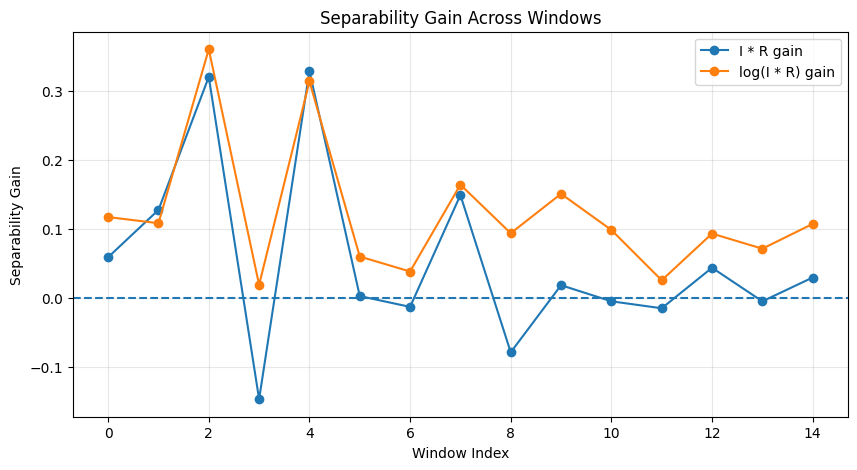

In [13]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(multi_sep_df))

plt.figure(figsize=(10, 5))

plt.plot(x, multi_sep_df["gain_IR"], marker='o', label="I * R gain")
plt.plot(x, multi_sep_df["gain_log"], marker='o', label="log(I * R) gain")

plt.axhline(0, linestyle='--')

plt.xlabel("Window Index")
plt.ylabel("Separability Gain")
plt.title("Separability Gain Across Windows")
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

## Interpretation: Separability Gain Across Windows

We visualized the separability gain of each proxy across all windows.

### Observations

- The proxy $I \cdot R$ shows **high variability**:
  - strong positive gains in some windows,
  - **clear negative dips** in others (e.g., window 3, window 8),
  - indicating unstable behavior across different scene conditions.

- The log-scaled proxy $\log(1 + I \cdot R)$ shows:
  - **consistently positive gains across most windows**,
  - significantly reduced negative dips,
  - smoother variation compared to $I \cdot R$.

### Key Insight

$$
I \cdot R \rightarrow \text{highly expressive but unstable}
$$

$$
\log(1 + I \cdot R) \rightarrow \text{more stable and consistently beneficial}
$$

### Interpretation

The plot demonstrates that:

- direct range compensation can produce large gains,
  but is sensitive to scene structure and can fail,
- log scaling mitigates these failures by:
  - reducing extreme values,
  - stabilizing distributions,
  - and improving robustness across windows.

### Takeaway

> The proxy does not uniformly improve semantic separability, but the log-scaled variant provides a more reliable and consistent improvement across temporal segments.

In [14]:
multi_sep_df.to_csv("../results/multiwindow_separability.csv", index=False)

## Conclusion

In this notebook, we evaluated the semantic usefulness of range-aware proxy signals across multiple windows of sequence 00.

The analysis focused on:

- class-wise signal structure,
- multiclass separability,
- and consistency of gains across temporal segments.

### Key Findings

- The direct proxy $I \cdot R$ shows **high variability**:
  - strong improvements in some windows,
  - but clear degradation in others,
  - indicating sensitivity to scene composition and geometry.

- The log-scaled proxy $\log(1 + I \cdot R)$ provides:
  - **more consistent positive gains across windows**,
  - reduced failure cases,
  - smoother behavior across temporal segments.

- Improvements are **not uniform**:
  - gains vary across windows,
  - some segments show weak or negligible improvement,
  - confirming that proxy effectiveness is **scene-dependent**.

### Interpretation

The results demonstrate that:

> range-aware transformations can improve semantic separability, but only when combined with appropriate stabilization.

Direct scaling introduces instability, while controlled transformations such as log scaling:

- preserve structure,
- reduce extreme effects,
- and improve robustness across windows.

### Core Takeaway

$$
I \cdot R \rightarrow \text{expressive but unstable}
$$

$$
\log(1 + I \cdot R) \rightarrow \text{balanced and robust}
$$

### Final Statement

This notebook establishes that:

- proxy usefulness must be evaluated across multiple windows,
- improvements are conditional, not universal,
- and stable proxy design is critical for reliable semantic enhancement.

These results provide the strongest evidence in the project so far and directly motivate:

**explicit failure-case analysis in the next stage.**

---